In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import sqlite3

df= pd.read_csv('tourney_results_cleaned.csv')
# Force-drop the "second attempt" placeholder rows
df = df[df['Pick 1'] != "I did not play a second attempt."].copy()
df = df[df['Pick 2'] != "I did not play a second attempt."].copy()


In [2]:
%run cleaner.ipynb

Processing: dirty results\F22W1.csv
Processing: dirty results\F22W2.csv
Processing: dirty results\F22W3.csv
Processing: dirty results\F22W4.csv
Processing: dirty results\F22W5.csv
Processing: dirty results\F22W6.csv
Processing: dirty results\F22W7.csv
Processing: dirty results\F22W8.csv
Processing: dirty results\F22W9.csv
Processing: dirty results\F23W1.csv
Processing: dirty results\F23W10.csv
Processing: dirty results\F23W2.csv
Processing: dirty results\F23W3.csv
Processing: dirty results\F23W4.csv
Processing: dirty results\F23W5.csv
Processing: dirty results\F23W6.csv
Processing: dirty results\F23W7.csv
Processing: dirty results\F23W8.csv
Processing: dirty results\F23W9.csv
Processing: dirty results\F24W1.csv
Processing: dirty results\F24W2.csv
Processing: dirty results\F24W3.csv
Processing: dirty results\F24W4.csv
Processing: dirty results\F24W5.csv
Processing: dirty results\F24W6.csv
Processing: dirty results\F24W7.csv
Processing: dirty results\F25W1.csv
Processing: dirty results\F

In [3]:
df.head()

,Pod,Rank,Victory\nPile 1,Victory\nPile 2,Turns,Win Points,Escaped Villains,Turns Points,Points per Turn,Escape Points,PPT Points,Bystanders Rescued,Fun Level,Pick 1,Pick 2,is_win,Unique_Pod_ID,Base
0,1.0,1,57.0,24.0,3,31,1,0,2,2.613,NaN,2.0,1.0,Gamora (MCU),Drax (MCU),0,F22_Pod_1,Gamora
1,1.0,2,35.0,57.0,6,34,3,1,1,2.706,NaN,6.0,4.0,Warlock,Gamora (MCU),0,F22_Pod_1,Warlock
2,1.0,3,57.0,20.0,5,33,1,0,4,2.333,NaN,2.0,5.0,Crystal,Queen Storm of Wakanda,0,F22_Pod_1,Crystal
3,1.0,4,12.0,55.0,1,30,4,2,5,2.233,NaN,1.0,5.0,Drax (MCU),Sunspot,0,F22_Pod_1,Drax
4,1.0,5,38.0,39.0,4,32,5,3,3,2.406,NaN,3.0,5.0,King Black Panther,Queen Storm of Wakanda,0,F22_Pod_1,King Black Panther


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5673 entries, 0 to 5672
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Pod                 5673 non-null   float64
 1   Rank                5673 non-null   int64  
 2   Victory
Pile 1      4856 non-null   float64
 3   Victory
Pile 2      4856 non-null   float64
 4   Turns               4158 non-null   object 
 5   Win Points          4158 non-null   object 
 6   Escaped Villains    4158 non-null   object 
 7   Turns Points        4158 non-null   object 
 8   Points per Turn     4158 non-null   object 
 9   Escape Points       4158 non-null   object 
 10  PPT Points          2681 non-null   object 
 11  Bystanders Rescued  3472 non-null   float64
 12  Fun Level           3497 non-null   float64
 13  Pick 1              3892 non-null   object 
 14  Pick 2              3892 non-null   object 
 15  is_win              5673 non-null   int64  
 16  Unique

In [5]:
df['Unique_Pod_ID'].unique()

array(['F22_Pod_1', 'F22_Pod_2', 'F22_Pod_3', 'F22_Pod_4', 'F22_Pod_5',
       'F22_Pod_6', 'F22_Pod_7', 'F22_Pod_8', 'F22_Pod_9', 'F22_Pod_10',
       'F22_Pod_11', 'F22_Pod_12', 'F22_Pod_13', 'F22_Pod_14',
       'F22_Pod_15', 'F22_Pod_16', 'F22_Pod_17', 'F22_Pod_18',
       'F22_Pod_19', 'F22_Pod_20', 'F22_Pod_21', 'F22_Pod_22',
       'F22_Pod_101', 'F22_Pod_23', 'F22_Pod_24', 'F22_Pod_25',
       'F22_Pod_26', 'F22_Pod_102', 'F22_Pod_27', 'F22_Pod_28',
       'F22_Pod_29', 'F22_Pod_103', 'F22_Pod_30', 'F22_Pod_31',
       'F22_Pod_32', 'F22_Pod_104', 'F22_Pod_33', 'F22_Pod_105',
       'F22_Pod_34', 'F22_Pod_107', 'F23_Pod_1', 'F23_Pod_2', 'F23_Pod_3',
       'F23_Pod_4', 'F23_Pod_5', 'F23_Pod_6', 'F23_Pod_7', 'F23_Pod_8',
       'F23_Pod_36', 'F23_Pod_120', 'F23_Pod_121', 'F23_Pod_122',
       'F23_Pod_9', 'F23_Pod_10', 'F23_Pod_11', 'F23_Pod_12',
       'F23_Pod_13', 'F23_Pod_14', 'F23_Pod_15', 'F23_Pod_16',
       'F23_Pod_17', 'F23_Pod_18', 'F23_Pod_19', 'F23_Pod_20',
       '

In [6]:
# 1. Define the columns to carry over
# REMOVED the stand-alone 'PPT' here because it likely doesn't exist in your raw df yet
metric_cols = ['is_win', 'Escaped Villains', 'PPT Points', 'Bystanders Rescued', 'Fun Level']
hero_cols = ['Pick 2', 'Pick 1']

# 2. Create the unified map
hero_win_map = df.melt(
    id_vars=metric_cols, 
    value_vars=hero_cols, 
    value_name='Hero'
)

# 2.5 SAFETY STEP: Force metrics to be numeric
for col in metric_cols:
    hero_win_map[col] = pd.to_numeric(hero_win_map[col], errors='coerce').fillna(0)

# 3. Clean junk and nulls
junk_phrase = 'I did not make a second attempt.'
hero_win_map = hero_win_map[(hero_win_map['Hero'] != junk_phrase) & hero_win_map['Hero'].notna()]

# 4. Generate the shared stats dataframe with Averages
# FIXED: Pointed 'PPT' to the actual column name 'PPT Points'
win_stats = hero_win_map.groupby('Hero').agg(
    Win_Rate=('is_win', 'mean'),
    Game_Appeared_In=('is_win', 'count'),
    PPT_Avg=('PPT Points', 'mean'), # Renamed to PPT_Avg to avoid confusion
    Escaped=('Escaped Villains', 'mean'),
    Bystanders=('Bystanders Rescued', 'mean'),
    Fun_Score=('Fun Level', 'mean')
).reset_index()

# 5. Apply the threshold
pop_min = 40
filtered_stats = win_stats[win_stats['Game_Appeared_In'] >= pop_min].copy()
unfiltered_stats = win_stats.copy()

# Verification
print(filtered_stats.tail())

                    Hero  Win_Rate  Game_Appeared_In   PPT_Avg   Escaped  \
239                Storm  0.480769                52  1.331846  2.769231   
241           Strong Guy  0.581395                43  1.720140  2.813953   
254                Thing  0.553191                47  1.496064  3.829787   
285  Wolverine (X-Force)  0.572650               117  1.780744  2.384615   
286    Wolverine (X-Men)  0.416667                60  1.387633  3.283333   

     Bystanders  Fun_Score  
239    6.346154   2.480769  
241    7.976744   3.325581  
254    7.340426   3.361702  
285    7.675214   3.564103  
286    7.900000   2.966667  


In [7]:
# 1. Define the Z-score for 95% Confidence
z = 1.96

# 2. Calculate the Margin of Error (as a percentage)
p = filtered_stats['Win_Rate']
n = filtered_stats['Game_Appeared_In']

# Calculate the raw margin of error
filtered_stats['MoE_Perc'] = (z * np.sqrt((p * (1 - p)) / n)) * 100

# 3. Create the Display String (e.g., "75.0% ± 8.2%")
filtered_stats['Win_Per'] = (
    (filtered_stats['Win_Rate'] * 100).round(1).astype(str) + "% ± " + 
    filtered_stats['MoE_Perc'].round(1).astype(str) + "%"
)

# 4. Sorting Logic
# Even though we are showing ±, we should still sort by the "Floor" 
# (Win_Rate - MoE) to reward consistency over luck.
filtered_stats['Rank_Value'] = (filtered_stats['Win_Rate'] * 100) - filtered_stats['MoE_Perc']
leaderboard = filtered_stats.sort_values(by='Rank_Value', ascending=False).reset_index(drop=True)

# 5. Select Final Columns for Display
# Changed 'PPT' to 'PPT_Avg' (or whatever name you used in the .agg() step)
final_display = leaderboard[['Hero', 'Win_Per', 'Game_Appeared_In', 'PPT_Avg', 'Fun_Score']]

print(f"Top 10 Heroes by Confidence (Min {pop_min} games):")
final_display.head(10)

Top 10 Heroes by Confidence (Min 40 games):


,Hero,Win_Per,Game_Appeared_In,PPT_Avg,Fun_Score
0,"Gamora, Destroyer of Thanos",87.3% ± 8.8%,55,2.707836,3.181818
1,Apocalyptic Black Widow,87.5% ± 9.4%,48,2.806604,3.500000
2,King Black Panther,85.1% ± 10.2%,47,2.239404,3.787234
3,Quake,72.5% ± 12.2%,51,2.233490,3.294118
4,Agent Phil Coulson,71.9% ± 11.7%,57,2.308772,2.789474
5,Mockingbird,66.7% ± 8.8%,111,2.167685,3.405405
6,Deathlok,66.3% ± 9.8%,89,2.187449,3.337079
7,Star-Lord,62.9% ± 9.2%,105,1.680943,3.523810
8,Gamora,62.9% ± 11.3%,70,1.572386,3.485714
9,Invisible Woman,59.1% ± 9.0%,115,1.846843,3.182609


In [8]:
filtered_stats['Hero'].unique()

array(['Agent Phil Coulson', 'Amadeus Cho', 'Angel', 'Ant-Man (Ant-Man)',
       'Apocalyptic Black Widow', 'Apocalyptic Kitty Pryde', 'Banshee',
       'Beast (Illuminati)', 'Beta Ray Bill', 'Bishop',
       'Black Panther (Illuminati)', 'Black Widow (Avengers)',
       'Brainstorm', 'Bruce Banner (World War Hulk)',
       'Captain America (Core)', 'Captain Marvel (Secret Wars Vol. 1)',
       'Colossus', 'Cyclops', 'Darkhawk', 'Deathlok', 'Domino', 'Elektra',
       'Fantastic Four United', 'Forge', 'Gambit', 'Gamora',
       'Gamora, Destroyer of Thanos', 'Gladiator Hulk', 'Groot',
       'Hawkeye', 'Hiroim', 'Hulk', 'Hulkbuster Iron Man', 'Human Torch',
       'Iceman', 'Invisible Woman', 'Iron Fist', 'Iron Man', 'Jean Grey',
       'Joe Fixit, Grey Hulk', 'King Black Panther', 'Lady Thor', 'M',
       'Mockingbird', 'Moon Knight', 'Mr. Fantastic', 'Phyla-Vell',
       'Punisher', 'Quake', 'Rogue', 'Shatterstar', 'She-Hulk',
       'Silver Surfer', 'Siryn', 'Spider-Woman', 'Star-Lo

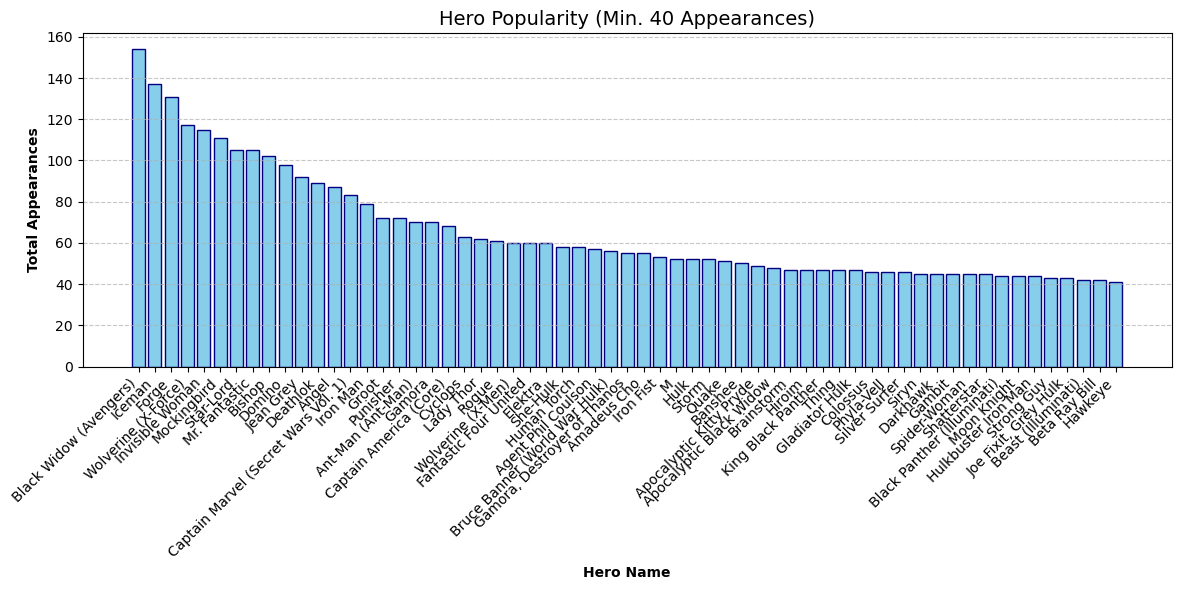

In [9]:
# Sort by appearance count
pop_plot_data = filtered_stats.sort_values('Game_Appeared_In', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(pop_plot_data['Hero'], pop_plot_data['Game_Appeared_In'], color='skyblue', edgecolor='navy')

plt.xlabel('Hero Name', fontweight='bold')
plt.ylabel('Total Appearances', fontweight='bold')
plt.title(f'Hero Popularity (Min. {pop_min} Appearances)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

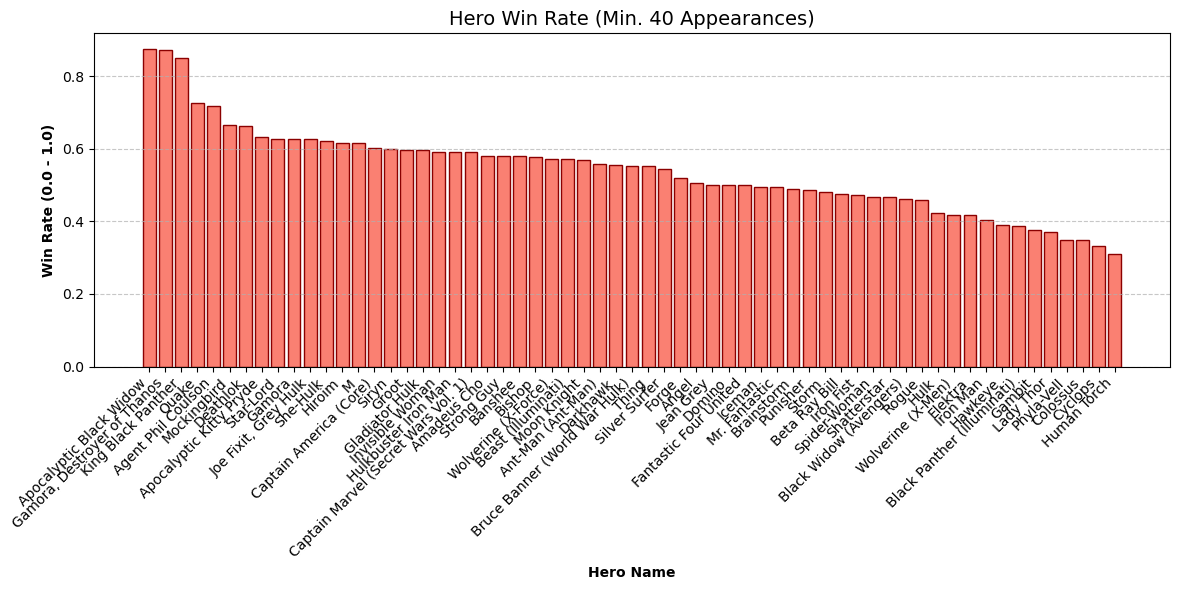

                            Hero  Win_Rate  Game_Appeared_In
9        Apocalyptic Black Widow  0.875000                48
92   Gamora, Destroyer of Thanos  0.872727                55
133           King Black Panther  0.851064                47
192                        Quake  0.725490                51
1             Agent Phil Coulson  0.719298                57
154                  Mockingbird  0.666667               111
63                      Deathlok  0.662921                89
10       Apocalyptic Kitty Pryde  0.632653                49
232                    Star-Lord  0.628571               105
90                        Gamora  0.628571                70


In [10]:
# Sort by win rate percentage
win_plot_data = filtered_stats.sort_values('Win_Rate', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(win_plot_data['Hero'], win_plot_data['Win_Rate'], color='salmon', edgecolor='darkred')

plt.xlabel('Hero Name', fontweight='bold')
plt.ylabel('Win Rate (0.0 - 1.0)', fontweight='bold')
plt.title(f'Hero Win Rate (Min. {pop_min} Appearances)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

# Print the raw numbers for verification
print(win_plot_data[['Hero', 'Win_Rate', 'Game_Appeared_In']].head(10))

In [11]:
topTenRanked=['Iceman', 'Mockingbird', 'Star-Lord', 'Banshee','Werewolf by Night','The Ancient One','Ant-Man (Ant-Man)','Captain America (Core)','Stingray','Jubilee']

In [12]:
# 1. Calculate global rankings for all heroes (higher win rate = rank 1)
win_stats['Global_Rank'] = win_stats['Win_Rate'].rank(ascending=False, method='min').astype(int)

# 2. Filter for community favorites
community_comparison = win_stats[win_stats['Hero'].isin(topTenRanked)].copy()

# 3. Sort by win rate
community_comparison = community_comparison.sort_values('Win_Rate', ascending=False)

# 4. Display result with the new rank column
print("Community Favorites vs. Global Win Rate Rank")
print(community_comparison[['Hero', 'Win_Rate', 'Global_Rank', 'Game_Appeared_In']])

Community Favorites vs. Global Win Rate Rank
                       Hero  Win_Rate  Global_Rank  Game_Appeared_In
279       Werewolf by Night  0.842105           33                38
154             Mockingbird  0.666667           80               111
232               Star-Lord  0.628571           94               105
37   Captain America (Core)  0.602941          109                68
13                  Banshee  0.580000          133                50
7         Ant-Man (Ant-Man)  0.557143          144                70
238                Stingray  0.529412          162                17
117                  Iceman  0.496350          186               137
128                 Jubilee  0.153846          275                13
248         The Ancient One  0.000000          279                10


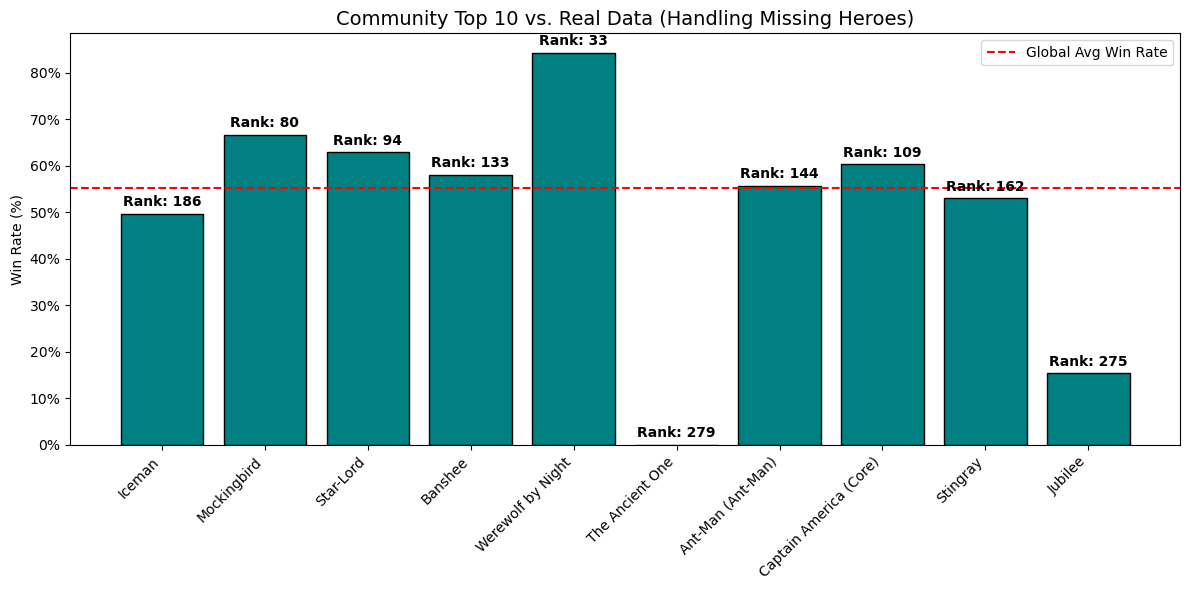

In [13]:
# 1. Create the comparison dataframe (using how='left' ensures all 10 stay)
community_df = pd.DataFrame({
    'Hero': topTenRanked,
    'Community_Rank': range(1, 11)
})
comparison_df = community_df.merge(win_stats, on='Hero', how='left')

# 2. Visualization
plt.figure(figsize=(12, 6))
# Fill NaN with 0 only for the bar height so the bar exists (at 0) or is omitted
bars = plt.bar(comparison_df['Hero'], comparison_df['Win_Rate'].fillna(0), 
               color='teal', edgecolor='black')

# 3. Handle labels for missing data
for bar, rank in zip(bars, comparison_df['Global_Rank']):
    height = bar.get_height()
    if pd.isna(rank):
        # Place label at the bottom if no data exists
        plt.text(bar.get_x() + bar.get_width()/2, 0.01, 
                 'No Data', ha='center', va='bottom', 
                 color='red', fontweight='bold', rotation=90)
    else:
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
                 f'Rank: {int(rank)}', ha='center', va='bottom', fontweight='bold')

plt.axhline(win_stats['Win_Rate'].mean(), color='red', linestyle='--', label='Global Avg Win Rate')
plt.title('Community Top 10 vs. Real Data (Handling Missing Heroes)', fontsize=14)
plt.ylabel('Win Rate (%)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
print(df.columns.tolist())

['Pod', 'Rank', 'Victory\nPile 1', 'Victory\nPile 2', 'Turns', 'Win Points', 'Escaped Villains', 'Turns Points', 'Points per Turn', 'Escape Points', 'PPT Points', 'Bystanders Rescued', 'Fun Level', 'Pick 1', 'Pick 2', 'is_win', 'Unique_Pod_ID', 'Base']


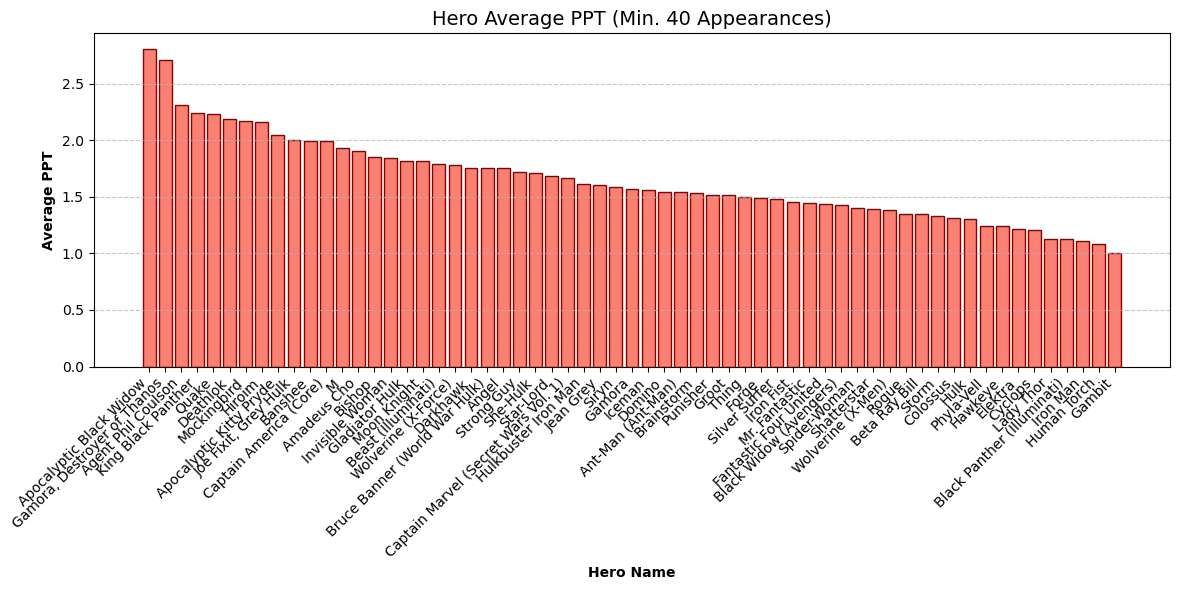

                            Hero   PPT_Avg  Game_Appeared_In
9        Apocalyptic Black Widow  2.806604                48
92   Gamora, Destroyer of Thanos  2.707836                55
1             Agent Phil Coulson  2.308772                57
133           King Black Panther  2.239404                47
192                        Quake  2.233490                51
63                      Deathlok  2.187449                89
154                  Mockingbird  2.167685               111
110                       Hiroim  2.160277                47
10       Apocalyptic Kitty Pryde  2.046776                49
127         Joe Fixit, Grey Hulk  2.005837                43


In [15]:
# 1. Sort by the column you actually want to plot
# Using the name from your previous .agg() step (e.g., 'PPT_Avg')
ppt_plot_data = filtered_stats.sort_values('PPT_Avg', ascending=False)

plt.figure(figsize=(12, 6))

# 2. FIXED: Use ppt_plot_data for both X and Y to keep them synced
plt.bar(ppt_plot_data['Hero'], ppt_plot_data['PPT_Avg'], color='salmon', edgecolor='darkred')

plt.xlabel('Hero Name', fontweight='bold')
plt.ylabel('Average PPT', fontweight='bold')

# 3. Update title
plt.title(f'Hero Average PPT (Min. {pop_min} Appearances)', fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. FIXED: Verification print using the correct dataframe
print(ppt_plot_data[['Hero', 'PPT_Avg', 'Game_Appeared_In']].head(10))

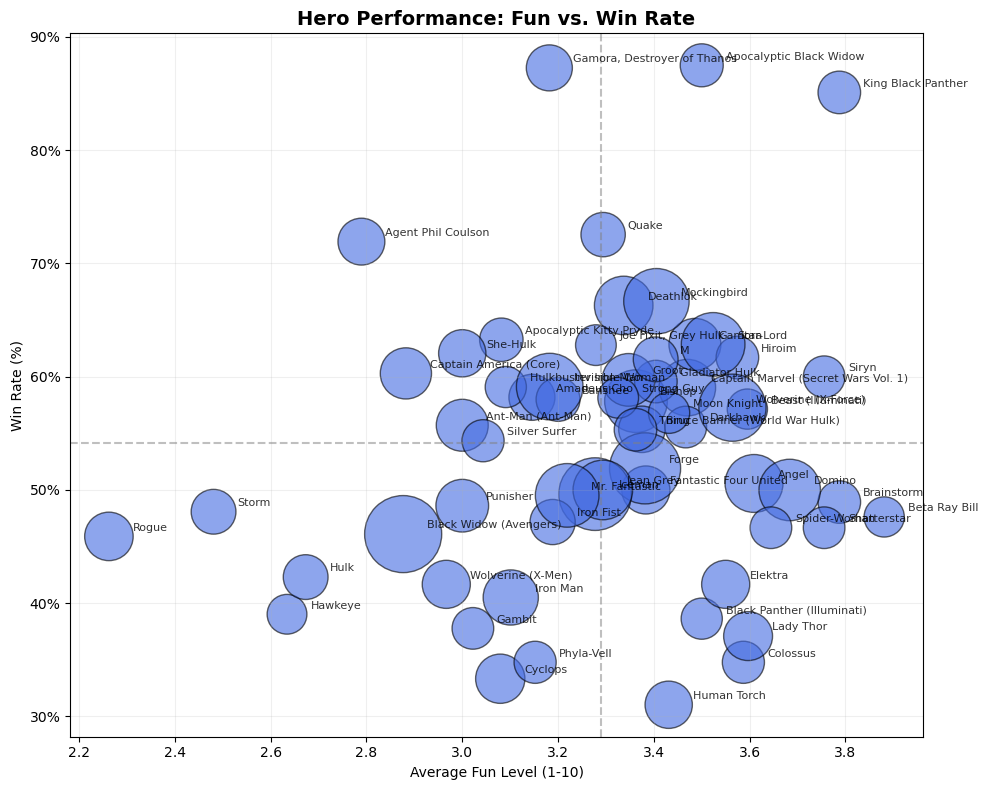

In [16]:
import seaborn as sns

# 1. Filter (Make sure we use the version of win_stats that has Fun_Score)
plot_data = win_stats[win_stats['Game_Appeared_In'] >= pop_min].copy()

plt.figure(figsize=(10, 8))

# 2. Scatter - UPDATED 'Fun' to 'Fun_Score'
plt.scatter(
    plot_data['Fun_Score'], 
    plot_data['Win_Rate'], 
    s=plot_data['Game_Appeared_In'] * 20, 
    alpha=0.6, 
    color='royalblue', 
    edgecolors="black"
)

# 3. Annotations - UPDATED 'Fun' to 'Fun_Score'
for x, y, label in zip(plot_data['Fun_Score'], plot_data['Win_Rate'], plot_data['Hero']):
    plt.text(x + 0.05, y + 0.005, label, fontsize=8, alpha=0.8)

# 4. Averages - UPDATED 'Fun' to 'Fun_Score'
plt.axvline(plot_data['Fun_Score'].mean(), color='grey', linestyle='--', alpha=0.5)
plt.axhline(plot_data['Win_Rate'].mean(), color='grey', linestyle='--', alpha=0.5)

# 5. Labels
plt.title('Hero Performance: Fun vs. Win Rate', fontsize=14, fontweight='bold')
plt.xlabel('Average Fun Level (1-10)')
plt.ylabel('Win Rate (%)')

# Formatting the Y-axis to show percentages
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [17]:
## --- HERO LOOKUP (NO MINIMUM GAMES) ---

# 1. Your list
target_heroes = ["Black Widow", "Black Widow (Avengers)", "Black Widow (Shield)","",""]
z = 1.96

# 2. Perform all calculations on the FULL unfiltered_stats first
p = unfiltered_stats['Win_Rate']
n = unfiltered_stats['Game_Appeared_In']
unfiltered_stats['MoE_Perc'] = (z * np.sqrt((p * (1 - p)) / n)) * 100

# Now the column 'Win_Per' actually exists in unfiltered_stats
unfiltered_stats['Win_Per'] = (
    (unfiltered_stats['Win_Rate'] * 100).round(1).astype(str) + "% ± " + 
    unfiltered_stats['MoE_Perc'].round(1).astype(str) + "%"
)

unfiltered_stats['Rank_Value'] = (unfiltered_stats['Win_Rate'] * 100) - unfiltered_stats['MoE_Perc']

# 3. NOW create the lookup (after columns are created)
search_list = [normalize_hero(h) for h in target_heroes]
hero_lookup = unfiltered_stats[unfiltered_stats['Hero'].isin(search_list)].copy()

# 4. Display
if hero_lookup.empty:
    print("No matches found in the master data. Check spelling!")
else:
    print(f"Stats for requested Hero Set (Ignoring pop_min):")
    display_cols = ['Hero', 'Win_Per', 'Game_Appeared_In', 'PPT_Avg', 'Fun_Score']
    # This will now work because 'Win_Per' exists in hero_lookup
    display(hero_lookup[display_cols])

Stats for requested Hero Set (Ignoring pop_min):


,Hero,Win_Per,Game_Appeared_In,PPT_Avg,Fun_Score
25,Black Widow (Avengers),46.1% ± 7.9%,154,1.428825,2.876623
26,Black Widow (SHIELD),73.5% ± 14.8%,34,2.096853,3.529412


In [18]:
# --- THE PICK-CHECKER ---

# 1. Input your potential picks here
my_picks = target_heroes

# 2. Process
search_list = [normalize_hero(h) for h in my_picks]
check_df = unfiltered_stats[unfiltered_stats['Hero'].isin(search_list)].copy()

if check_df.empty:
    print("⚠️ No data found for these heroes. Check your spelling!")
else:
    # Math for the Team
    team_win = check_df['Win_Rate'].mean()
    avg_n = check_df['Game_Appeared_In'].mean()
    moe = (1.96 * np.sqrt((team_win * (1 - team_win)) / avg_n))
    
    low_end = (team_win - moe) * 100
    high_end = (team_win + moe) * 100
    spread = high_end - low_end

    # DISPLAY RESULTS
    print(f"--- PRE-GAME ANALYSIS: {', '.join(check_df['Hero'].tolist())} ---")
    print(f"Average Hero Win Rate: {team_win*100:.1f}%")
    print(f"Reliability Window: {low_end:.1f}% to {high_end:.1f}%")
    
    # 3. STRATEGIC ADVICE
    if spread > 35:
        print("\n🚩 WARNING: HIGH VOLATILITY. Data is thin for this team. Proceed with caution.")
    
    if low_end > 55:
        print("\n✅ SOLID PICK: Even at their worst, this group statistically wins.")
    elif high_end < 45:
        print("\n❌ AVOID: This team has a low statistical ceiling. Expect a struggle.")
    elif low_end < 40 and high_end > 60:
        print("\n⚖️ WILD CARD: This team is capable of winning, but highly inconsistent.")
    else:
        print("\nOK: A standard-performing team.")

    # Show the individual stats for the heroes you picked
    display(check_df[['Hero', 'Win_Per', 'Game_Appeared_In', 'PPT_Avg']].sort_values(by='Game_Appeared_In', ascending=False))

--- PRE-GAME ANALYSIS: Black Widow (Avengers), Black Widow (SHIELD) ---
Average Hero Win Rate: 59.8%
Reliability Window: 49.9% to 69.7%

OK: A standard-performing team.


,Hero,Win_Per,Game_Appeared_In,PPT_Avg
25,Black Widow (Avengers),46.1% ± 7.9%,154,1.428825
26,Black Widow (SHIELD),73.5% ± 14.8%,34,2.096853


In [19]:

# --- DEBUG: FINDING THE "2" GLITCH ---

# 1. Look for rows where 'Pick 2' is exactly the string "2"
# We check for both the string '2' and the number 2 just in case
glitch_rows = df[
    (df['Pick 2'] == '7') | 
    (df['Pick 2'] == 7)
].copy()

# 2. Check the count
if glitch_rows.empty:
    print("No rows found where Pick 2 equals '2'.")
    print("Checking for partial matches...")
    # This helps if it's "2 " or "2.0"
    partial_matches = df[df['Pick 2'].astype(str).str.contains('^2$', regex=True)]
    display(partial_matches)
else:
    print(f"Found {len(glitch_rows)} rows with '2' in Pick 2:")
    # Show the full width so we can see if other columns shifted
    with pd.option_context('display.max_columns', None):
        display(glitch_rows)

# 3. Optional: Check the 'Pod' and 'Rank' of these rows
# Often if Pick 2 is a number, the whole row shifted one column to the right

No rows found where Pick 2 equals '2'.
Checking for partial matches...


,Pod,Rank,Victory\nPile 1,Victory\nPile 2,Turns,Win Points,Escaped Villains,Turns Points,Points per Turn,Escape Points,PPT Points,Bystanders Rescued,Fun Level,Pick 1,Pick 2,is_win,Unique_Pod_ID,Base


In [20]:

# 1. Define the Z-score for 95% Confidence
z = 1.96

# 2. Calculate the Margin of Error
p = filtered_stats['Win_Rate']
n = filtered_stats['Game_Appeared_In']
filtered_stats['MoE_Perc'] = (z * np.sqrt((p * (1 - p)) / n)) * 100

# 3. Create the Display String (Win Rate + Confidence Interval)
filtered_stats['Win_Per'] = (
    (filtered_stats['Win_Rate'] * 100).round(1).astype(str) + "% ± " + 
    filtered_stats['MoE_Perc'].round(1).astype(str) + "%"
)

# 4. Sorting Logic (Sorting by the "Lower Bound" of the 95% CI)
filtered_stats['Rank_Value'] = (filtered_stats['Win_Rate'] * 100) - filtered_stats['MoE_Perc']

# 5. Create Leaderboard
leaderboard = filtered_stats.sort_values(by='Rank_Value', ascending=False).reset_index(drop=True)

# 6. Final Display Selection
final_display = leaderboard[['Hero', 'Win_Per', 'Game_Appeared_In', 'PPT_Avg', 'Fun_Score']]

print(f"--- Top 10 Heroes by Win Rate (95% Confidence Level) ---")
display(final_display.head(10))

--- Top 10 Heroes by Win Rate (95% Confidence Level) ---


,Hero,Win_Per,Game_Appeared_In,PPT_Avg,Fun_Score
0,"Gamora, Destroyer of Thanos",87.3% ± 8.8%,55,2.707836,3.181818
1,Apocalyptic Black Widow,87.5% ± 9.4%,48,2.806604,3.500000
2,King Black Panther,85.1% ± 10.2%,47,2.239404,3.787234
3,Quake,72.5% ± 12.2%,51,2.233490,3.294118
4,Agent Phil Coulson,71.9% ± 11.7%,57,2.308772,2.789474
5,Mockingbird,66.7% ± 8.8%,111,2.167685,3.405405
6,Deathlok,66.3% ± 9.8%,89,2.187449,3.337079
7,Star-Lord,62.9% ± 9.2%,105,1.680943,3.523810
8,Gamora,62.9% ± 11.3%,70,1.572386,3.485714
9,Invisible Woman,59.1% ± 9.0%,115,1.846843,3.182609
